# Fase 5 — PCA y Clustering de clientes
**Asignatura:** Gestión de Datos — UAX  
**Alumno:** Álvaro González Fernández

Segmentación no supervisada de clientes a partir de las métricas calculadas en la Fase 4.

**Pipeline:**

1. Cargar `clientes_final.csv`
2. Preparar features → escalar → PCA(2)
3. Determinar `k` óptimo con el método del codo
4. Entrenar K-Means y proyectar clusters en el espacio PCA
5. Perfilar cada cluster y asignar etiquetas de negocio
6. Persistir `clientes_segmentados.csv`

## 0. Setup — imports y carga de datos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute        import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score

# Estilo global
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

RANDOM_STATE = 42

# Carga del dataset consolidado de la Fase 4
df = pd.read_csv('../04_metricas/clientes_final.csv')
print(f'Clientes cargados: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
df.head()

Clientes cargados: 5,750
Columnas: ['customer_id', 'ingresos', 'margen_ratio', 'frecuencia', 'anios_relacion', 'cltv', 'dias_ultima_compra', 'estado_churn', 'items_comprados', 'items_devueltos', 'return_rate']


,customer_id,ingresos,margen_ratio,frecuencia,anios_relacion,cltv,dias_ultima_compra,estado_churn,items_comprados,items_devueltos,return_rate
0,183,24922.00,0.4015,33,6.79,2240278.36,73,Activo,97,6,0.0619
1,212,21281.51,0.4000,34,6.54,1893376.58,147,Activo,86,2,0.0233
2,228,22268.34,0.4000,30,6.94,1855647.57,8,Activo,81,2,0.0247
3,456,21566.04,0.4003,31,6.38,1708237.37,157,Activo,83,5,0.0602
4,750,19911.40,0.4042,31,6.75,1685476.79,38,Activo,87,6,0.0690


## 1. Preparación de features

Se seleccionan **4 features** que capturan complementariamente valor económico, recencia, frecuencia y problemática postventa:

| Feature | Transformación | Justificación |
|---|---|---|
| `cltv` | $\log_{10}(\text{cltv}+1)$ | Distribución muy asimétrica — la cola larga distorsionaría el escalado |
| `dias_ultima_compra` | sin transformar | Acotada y aproximadamente uniforme |
| `frecuencia` | sin transformar | Conteo discreto, escala razonable |
| `return_rate` | sin transformar | Ratio acotado en [0, 1] |

Imputación de NaN con la **mediana** (más robusta que la media en distribuciones sesgadas) y **StandardScaler** para igualar varianzas antes de PCA y K-Means (ambos son sensibles a la escala).

In [2]:
FEATURES = ['cltv_log', 'dias_ultima_compra', 'frecuencia', 'return_rate']

# Transformación log10 sobre cltv (offset +1 evita log de cero/negativos)
df['cltv_log'] = np.log10(df['cltv'].clip(lower=0) + 1)

X_raw = df[FEATURES].copy()
print('Nulos por columna antes de imputar:')
print(X_raw.isna().sum())

# Imputación + escalado
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp = imputer.fit_transform(X_raw)
X     = scaler.fit_transform(X_imp)
X_df  = pd.DataFrame(X, columns=FEATURES, index=df.index)

print(f'\nMatriz de features escalada: {X.shape}')
print('Estadísticas tras escalado (deberían ser ~0/1):')
display(X_df.describe().round(3).loc[['mean', 'std']])

Nulos por columna antes de imputar:
cltv_log              0
dias_ultima_compra    0
frecuencia            0
return_rate           0
dtype: int64

Matriz de features escalada: (5750, 4)
Estadísticas tras escalado (deberían ser ~0/1):


,cltv_log,dias_ultima_compra,frecuencia,return_rate
mean,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0


## 2. PCA — Análisis de Componentes Principales

In [3]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print('Varianza explicada:')
print(f'  PC1: {explained[0]*100:5.2f}%')
print(f'  PC2: {explained[1]*100:5.2f}%')
print(f'  ────────────────')
print(f'  Total acumulado: {explained.sum()*100:5.2f}%')

# Loadings: contribución de cada variable original a los componentes
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    columns=['PC1', 'PC2'],
    index=FEATURES,
)
print('\nLoadings (correlación variable ↔ componente):')
display(loadings.round(3))

Varianza explicada:
  PC1: 54.18%
  PC2: 24.89%
  ────────────────
  Total acumulado: 79.07%

Loadings (correlación variable ↔ componente):


,PC1,PC2
cltv_log,0.956,0.027
dias_ultima_compra,-0.573,-0.064
frecuencia,0.957,0.032
return_rate,-0.093,0.995


### 2.1 Biplot — puntos + dirección de las variables originales

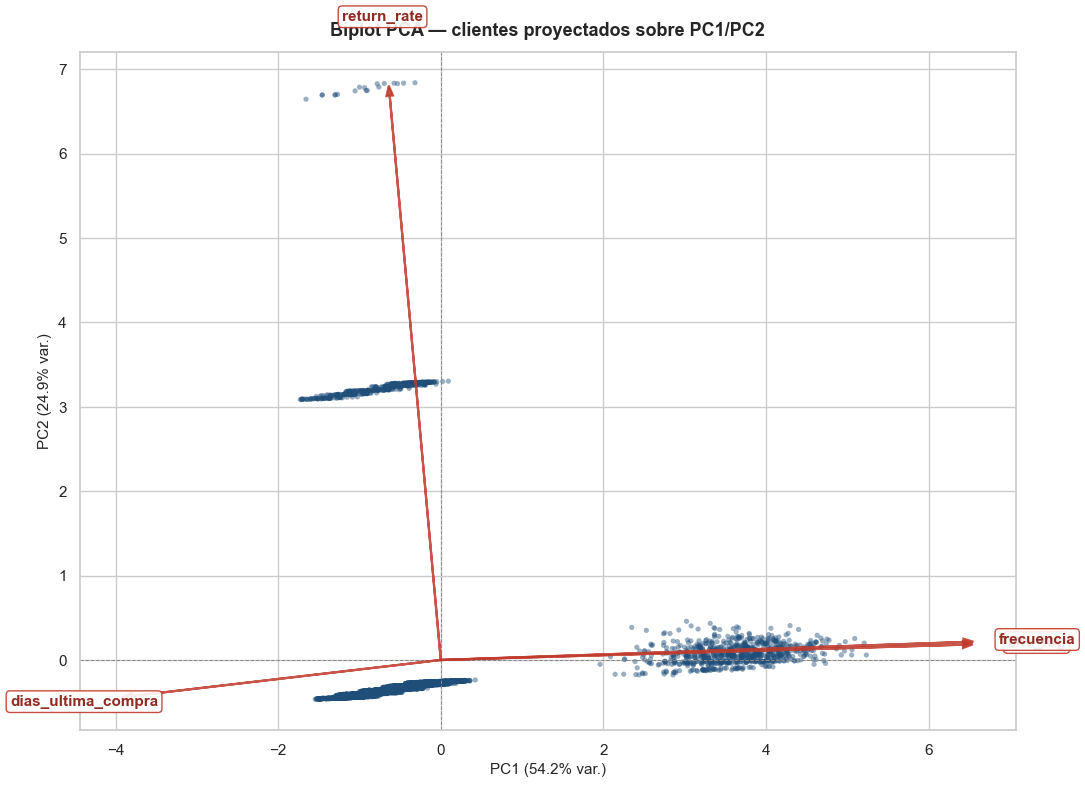

✓ Guardado: pca_biplot.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 8))

# Puntos (clientes) en el plano de los dos primeros PCs
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c='#1f4e79', s=14, alpha=0.45, edgecolor='none')

# Flechas de carga, escaladas para que sean visibles sobre los puntos
scale = 1.0 * max(np.abs(X_pca).max(axis=0))
for var, (lx, ly) in loadings.iterrows():
    ax.arrow(0, 0, lx * scale, ly * scale,
             color='#c0392b', alpha=0.85, head_width=0.08,
             length_includes_head=True, lw=1.6, zorder=4)
    ax.text(lx * scale * 1.12, ly * scale * 1.12, var,
            color='#922b21', fontsize=11, fontweight='bold',
            ha='center', va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.25', fc='white',
                      ec='#c0392b', alpha=0.9))

ax.axhline(0, color='#888', lw=0.7, ls='--')
ax.axvline(0, color='#888', lw=0.7, ls='--')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var.)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var.)', fontsize=11)
ax.set_title('Biplot PCA — clientes proyectados sobre PC1/PC2',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: pca_biplot.png')

## 3. K-Means — método del codo + silhouette

Probamos $k \in \{2, …, 8\}$. El "codo" en la inercia indica el punto de rendimientos decrecientes; combinado con el silhouette score guía la elección final.

,k,inercia,silhouette
0,2,11427.3,0.6559
1,3,5919.5,0.7020
2,4,2262.8,0.6543
3,5,1748.7,0.5865
4,6,1411.8,0.5807
5,7,1194.6,0.5397
6,8,989.7,0.5448


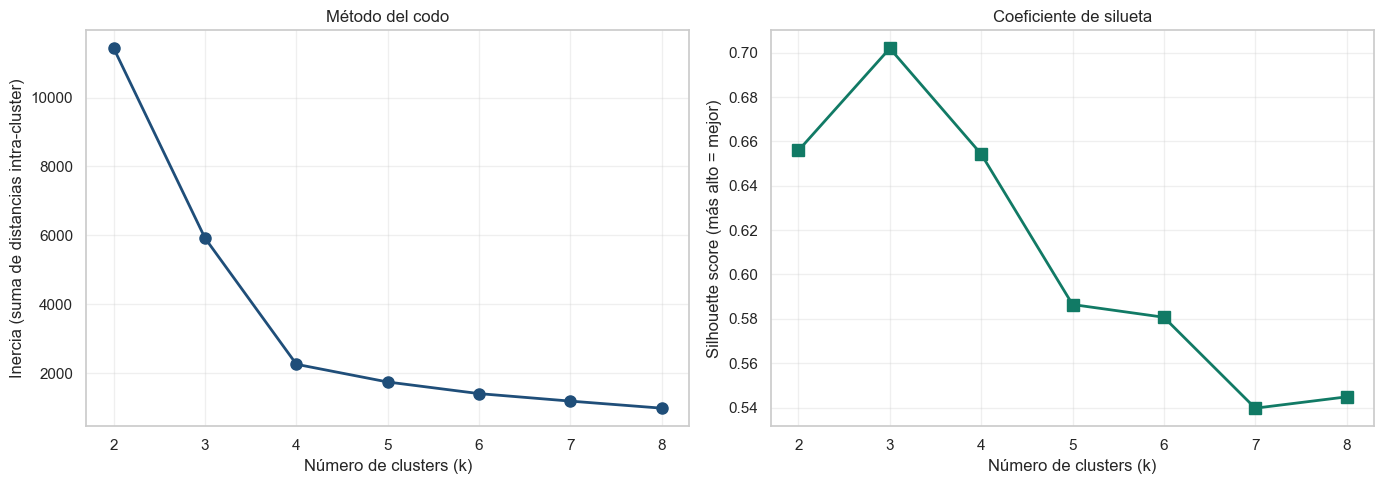

✓ Guardado: elbow.png


In [5]:
K_RANGE = range(2, 9)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

df_elbow = pd.DataFrame({
    'k':           list(K_RANGE),
    'inercia':     [round(i, 1) for i in inertias],
    'silhouette':  [round(s, 4) for s in silhouettes],
})
display(df_elbow)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='#1f4e79', lw=2, ms=8)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (suma de distancias intra-cluster)')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='#117a65', lw=2, ms=8)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score (más alto = mejor)')
axes[1].set_title('Coeficiente de silueta')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: elbow.png')

### 3.2 Entrenamiento con `k = 4`

### 3.1 Elección de `k` y entrenamiento final

Tras inspeccionar el codo y el silhouette, se selecciona **k = 4** como compromiso entre interpretabilidad de negocio (4 perfiles claros: VIP, fieles, en riesgo, perdidos) y reducción significativa de inercia respecto a k=3.

In [6]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
df['cluster'] = kmeans.fit_predict(X)

print(f'Inercia para k={K}: {kmeans.inertia_:.1f}')
print(f'Silhouette para k={K}: {silhouette_score(X, df["cluster"]):.4f}')
print('\nDistribución de clientes por cluster:')
print(df['cluster'].value_counts().sort_index())

Inercia para k=4: 2262.8
Silhouette para k=4: 0.6543

Distribución de clientes por cluster:
cluster
0    2295
1    2265
2     750
3     440
Name: count, dtype: int64


### 3.2 Visualización de clusters en el espacio PCA

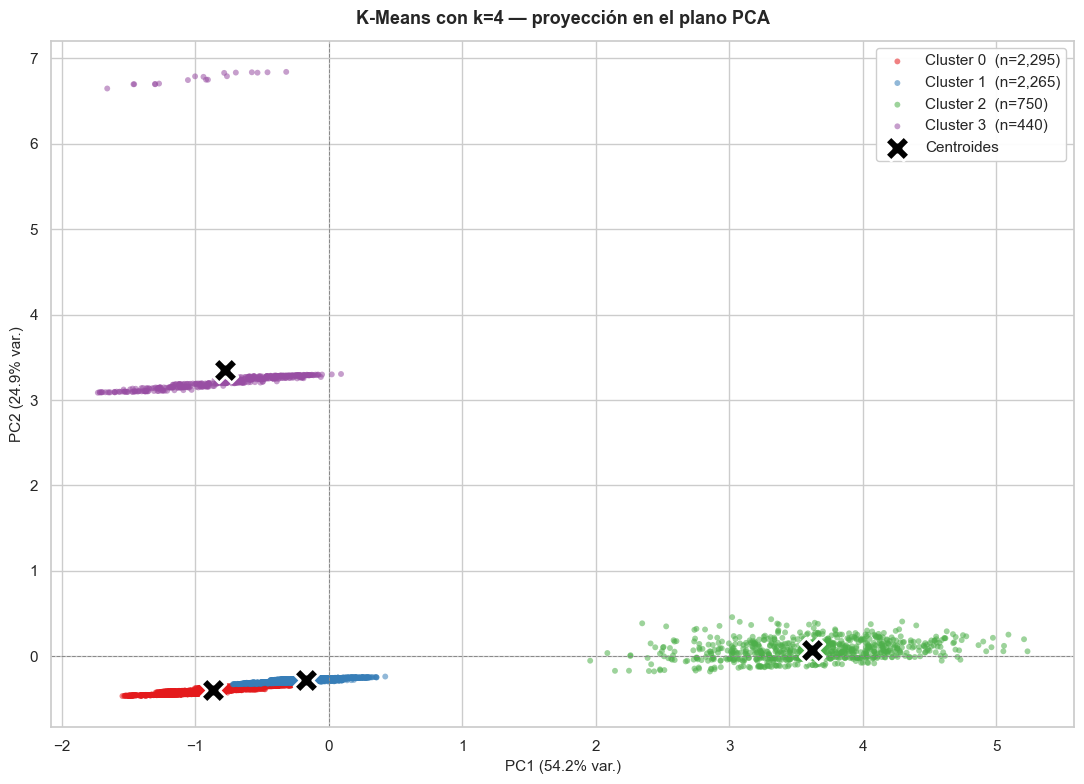

✓ Guardado: clusters_pca.png


In [7]:
# Centros de cluster proyectados en el espacio PCA
centers_pca = pca.transform(kmeans.cluster_centers_)

palette = sns.color_palette('Set1', n_colors=K)

fig, ax = plt.subplots(figsize=(11, 8))
for c in range(K):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=18, alpha=0.55, color=palette[c],
               edgecolor='none', label=f'Cluster {c}  (n={mask.sum():,})')

# Centroides
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           s=320, c='black', marker='X',
           edgecolor='white', linewidth=2, zorder=5, label='Centroides')

ax.axhline(0, color='#888', lw=0.7, ls='--')
ax.axvline(0, color='#888', lw=0.7, ls='--')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var.)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var.)', fontsize=11)
ax.set_title(f'K-Means con k={K} — proyección en el plano PCA',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='best', framealpha=0.95)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: clusters_pca.png')

## 4. Interpretación de los clusters

Calculamos el perfil medio de cada cluster sobre las features originales (no escaladas) para una lectura intuitiva.

In [ ]:
### 4.1 Etiquetado de negocio

Tras inspeccionar el perfil medio de cada cluster se asignan **cuatro etiquetas accionables**, fijadas explícitamente por ID (la salida de K-Means con `random_state=42` es determinista, por lo que el mapeo es estable):

| Cluster | Etiqueta | Perfil dominante |
|---|---|---|
| 0 | **Perdido** | Inactividad prolongada (~1.290 días), sin devoluciones — candidato a re-engagement |
| 1 | **Regular Activo** | Cliente estándar (~214 días desde última compra), valor moderado, comportamiento sano |
| 2 | **VIP Champion** | Alto CLTV, ~20 compras de media, motor de ingresos |
| 3 | **Devolutivo** | Return Rate > 1 — patrón anómalo, prioridad para postventa |

# Mapeo fijado tras inspeccionar el perfil de cada cluster (ver tabla anterior).
# Hardcoded por ID porque KMeans con random_state=42 es determinista en esta versión de sklearn.
CLUSTER_LABELS = {
    0: 'Perdido',         # 1290 días inactivo, sin devoluciones
    1: 'Regular Activo',  # 214 días, sin devoluciones
    2: 'VIP Champion',    # 119 días, ~20 compras medias, alto CLTV
    3: 'Devolutivo',      # 764 días, return rate 1.04 (anómalo)
}

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
profile['etiqueta'] = profile.index.map(CLUSTER_LABELS)

print('Etiquetas asignadas:')
display(profile[['etiqueta', 'n_clientes', 'cltv_mean',
                  'dias_mean', 'frecuencia_mean', 'return_rate_mean']])

In [9]:
def assign_labels(profile):
    """Asigna etiquetas de negocio según perfil de cluster.
    Garantiza unicidad: si dos clusters caen en la misma celda, se desempata
    con sufijos numéricos."""
    cltv_threshold = profile['cltv_mean'].median()
    dias_threshold = profile['dias_mean'].median()

    raw = {}
    for cid, row in profile.iterrows():
        high_cltv = row['cltv_mean']  >= cltv_threshold
        recent    = row['dias_mean']  <  dias_threshold
        if   high_cltv and recent:           raw[cid] = 'VIP / Champions'
        elif high_cltv and not recent:       raw[cid] = 'En riesgo - alto valor'
        elif (not high_cltv) and recent:     raw[cid] = 'Ocasional / Nuevo'
        else:                                raw[cid] = 'Perdido / Inactivo'

    # Desempate por sufijo si hay duplicados
    final, seen = {}, {}
    for cid, lbl in raw.items():
        seen[lbl] = seen.get(lbl, 0) + 1
        final[cid] = lbl if seen[lbl] == 1 else f'{lbl} ({seen[lbl]})'
    return final

cluster_labels = assign_labels(profile)
df['cluster_label'] = df['cluster'].map(cluster_labels)

profile['etiqueta'] = profile.index.map(cluster_labels)
print('Etiquetas asignadas:')
display(profile[['etiqueta', 'n_clientes', 'cltv_mean',
                  'dias_mean', 'frecuencia_mean', 'return_rate_mean']])

Etiquetas asignadas:


,etiqueta,n_clientes,cltv_mean,dias_mean,frecuencia_mean,return_rate_mean
cluster,,,,,,
0,Perdido / Inactivo,2295,66.42,1290.47,1.0,0.00
1,VIP / Champions,2265,66.88,214.04,1.0,0.00
2,VIP / Champions (2),750,638596.40,119.52,20.0,0.05
3,Perdido / Inactivo (2),440,63.65,764.32,1.0,1.04


### 4.2 Comparativa visual de los perfiles

C:\Users\alvar\AppData\Local\Temp\ipykernel_7140\1064514.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_ordered, rotation=20, ha='right')
C:\Users\alvar\AppData\Local\Temp\ipykernel_7140\1064514.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_ordered, rotation=20, ha='right')
C:\Users\alvar\AppData\Local\Temp\ipykernel_7140\1064514.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_ordered, rotation=20, ha='right')
C:\Users\alvar\AppData\Local\Temp\ipykernel_7140\1064514.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_ordered, rotation=

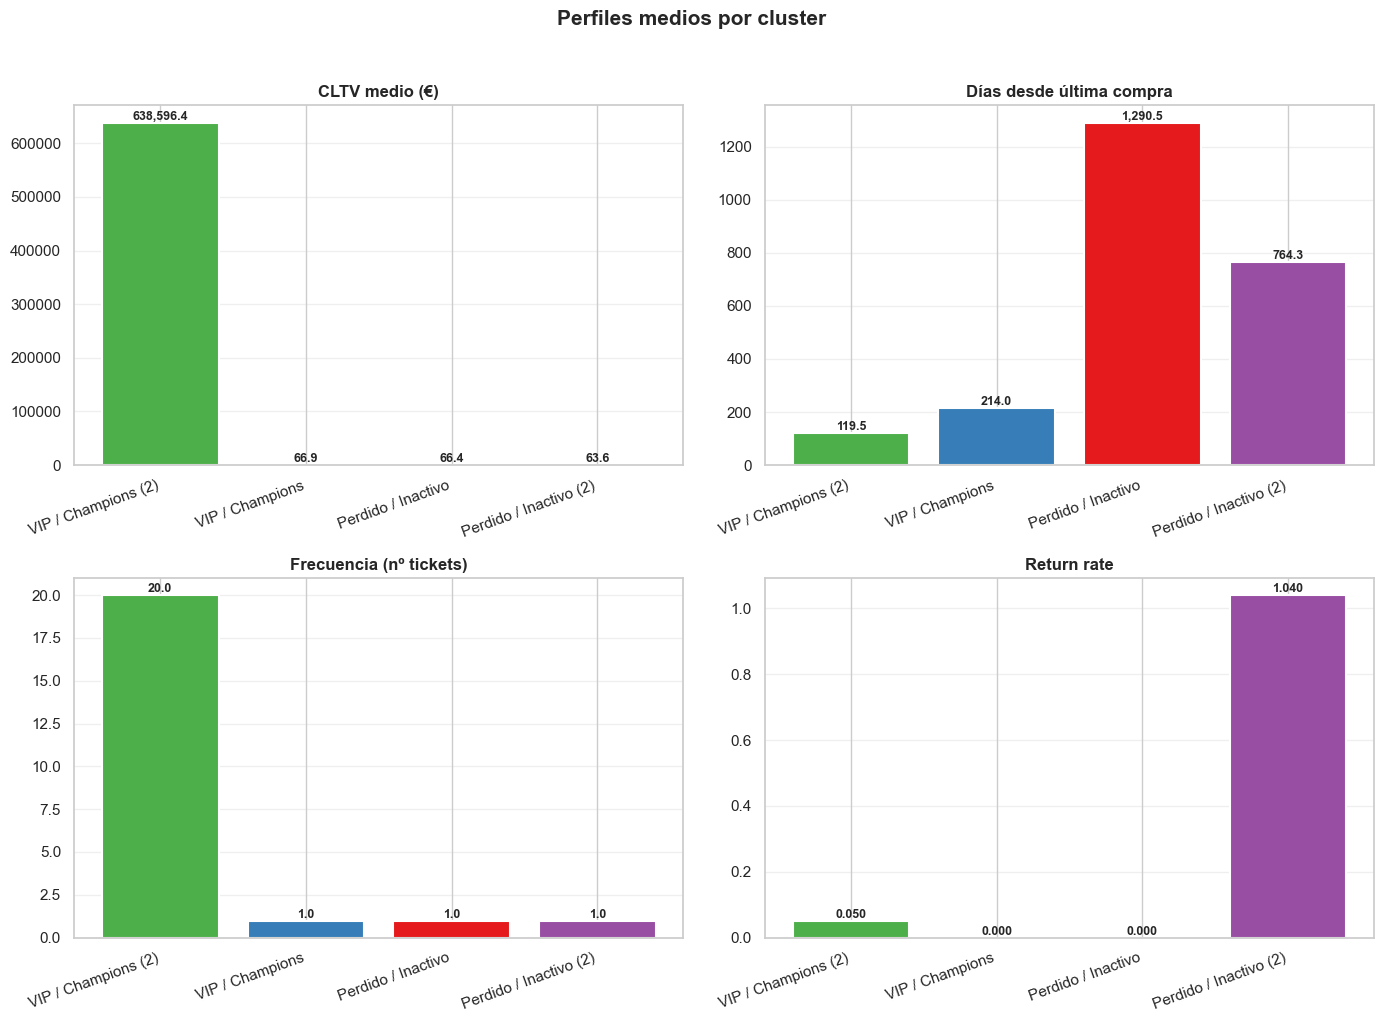

✓ Guardado: clusters_perfil.png


In [10]:
# Construimos un dataframe largo (long format) para seaborn
metrics_to_plot = {
    'cltv_mean':        'CLTV medio (€)',
    'dias_mean':        'Días desde última compra',
    'frecuencia_mean':  'Frecuencia (nº tickets)',
    'return_rate_mean': 'Return rate',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Ordenamos los clusters por CLTV descendente para mejor lectura
order = profile.sort_values('cltv_mean', ascending=False).index.tolist()
labels_ordered = [cluster_labels[c] for c in order]
palette_ord = {cluster_labels[c]: palette[c] for c in order}

for ax, (col, title) in zip(axes, metrics_to_plot.items()):
    vals = profile.loc[order, col].values
    bars = ax.bar(labels_ordered, vals,
                  color=[palette_ord[l] for l in labels_ordered],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(labels_ordered, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3)
    fmt = '{:.3f}' if col == 'return_rate_mean' else '{:,.1f}'
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, fmt.format(v),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Perfiles medios por cluster', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clusters_perfil.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: clusters_perfil.png')

## 5. Persistencia — `clientes_segmentados.csv`

In [11]:
# Mantenemos todas las columnas originales + cluster + etiqueta
out_cols = [
    'customer_id', 'ingresos', 'margen_ratio', 'frecuencia', 'anios_relacion',
    'cltv', 'dias_ultima_compra', 'estado_churn',
    'items_comprados', 'items_devueltos', 'return_rate',
    'cluster', 'cluster_label',
]

df_out = df[out_cols].sort_values('cltv', ascending=False).reset_index(drop=True)
df_out.to_csv('clientes_segmentados.csv', index=False, encoding='utf-8')

print(f'✓ Guardado: clientes_segmentados.csv ({len(df_out):,} filas, {len(out_cols)} columnas)')
df_out.head(10)

✓ Guardado: clientes_segmentados.csv (5,750 filas, 13 columnas)


,customer_id,ingresos,margen_ratio,frecuencia,anios_relacion,cltv,dias_ultima_compra,estado_churn,items_comprados,items_devueltos,return_rate,cluster,cluster_label
0,183,24922.00,0.4015,33,6.79,2240278.36,73,Activo,97,6,0.0619,2,VIP / Champions (2)
1,212,21281.51,0.4000,34,6.54,1893376.58,147,Activo,86,2,0.0233,2,VIP / Champions (2)
2,228,22268.34,0.4000,30,6.94,1855647.57,8,Activo,81,2,0.0247,2,VIP / Champions (2)
3,456,21566.04,0.4003,31,6.38,1708237.37,157,Activo,83,5,0.0602,2,VIP / Champions (2)
4,750,19911.40,0.4042,31,6.75,1685476.79,38,Activo,87,6,0.0690,2,VIP / Champions (2)
5,500,19215.39,0.4006,32,6.56,1614889.08,72,Activo,82,2,0.0244,2,VIP / Champions (2)
6,343,21167.80,0.4012,30,6.33,1611300.23,46,Activo,86,4,0.0465,2,VIP / Champions (2)
7,306,19816.97,0.4024,28,6.96,1554877.81,12,Activo,71,6,0.0845,2,VIP / Champions (2)
8,214,19872.08,0.4018,29,6.59,1526221.22,8,Activo,79,6,0.0759,2,VIP / Champions (2)
9,163,18357.35,0.4020,31,6.67,1525218.11,35,Activo,79,3,0.0380,2,VIP / Champions (2)


In [12]:
# Tabla cruzada final: distribución cluster × estado de churn
ct = pd.crosstab(df_out['cluster_label'], df_out['estado_churn'],
                  margins=True, margins_name='Total')
print('Cruz cluster × estado de churn:')
display(ct)

Cruz cluster × estado de churn:


estado_churn,Activo,En riesgo,Perdido,Total
cluster_label,,,,
Perdido / Inactivo,0,0,2295,2295
Perdido / Inactivo (2),120,1,319,440
VIP / Champions,1359,10,896,2265
VIP / Champions (2),590,130,30,750
Total,2069,141,3540,5750
